In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import numpy as np

sys.path.append("..")
from utils.psf_correction import PSFCorrection

from models.psf import KingPSF

import matplotlib.pyplot as plt

In [2]:
nside = 128

kp = KingPSF()

psf0 = PSFCorrection(delay_compute=True, num_f_bins=15, nside=nside, f_trunc=0.01)
psf0.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf0.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf0.psf_samples = 10000
psf0.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf0.make_or_load_psf_corr(force_recompute=True)

In [4]:
psf1 = PSFCorrection(
    delay_compute=True, num_f_bins='nonuni', nside=nside, f_trunc=0.00,
    n_psf=100000
)
psf1.psf_r_func = lambda r: kp.psf_fermi_r(r)
psf1.sample_psf_max = 10.0 * kp.spe * (kp.score + kp.stail) / 2.0
psf1.psf_samples = 10000
psf1.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf1.make_or_load_psf_corr(force_recompute=True)

In [26]:
# delta psf
psf1 = PSFCorrection(
    delay_compute=True, num_f_bins='nonuni', nside=nside, f_trunc=0.00,
    psf_sigma_deg=1e-6,
    n_psf=100000
)
psf1.sample_psf_max = 1e-6
psf1.psf_samples = 10000
psf1.psf_tag = f"Fermi_PSF_2GeV2_nside{nside}"
psf1.make_or_load_psf_corr(force_recompute=True)

npix_before = np.sum(psf1.df_rho_div_f_ary[1:] * psf1.f_ary[1:])
npix0 = 6839 - npix_before
psf1.df_rho_div_f_ary[0] = npix0 / psf1.f_ary[0]
psf1.df_rho_div_f_ary /= np.sum(psf1.df_rho_div_f_ary * psf1.f_ary**2)

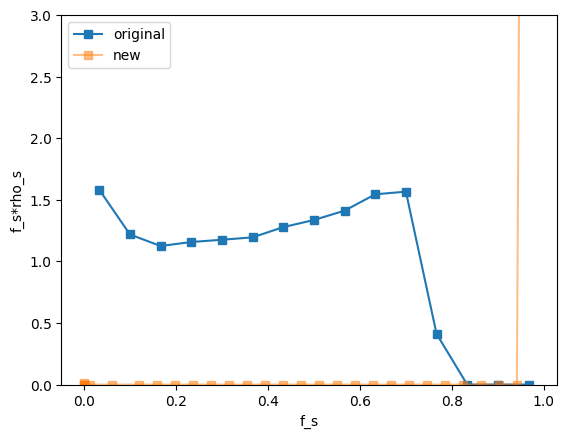

In [22]:
fig, ax = plt.subplots()
ax.plot(psf0.f_ary, psf0.f_ary*psf0.rho_ary, 's-', label='original')
ax.plot(psf1.f_ary, psf1.f_ary*psf1.rho_ary, 's-', alpha=0.5, label='new')
ax.set(xlabel='f_s', ylabel='f_s*rho_s')
ax.set(ylim=(0, 3))
ax.legend();

In [27]:
print(
    'original',
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary),
    np.sum(psf0.df_rho_div_f_ary * psf0.f_ary**2)
)
print(
    'deltapsf',
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary),
    np.sum(psf1.df_rho_div_f_ary * psf1.f_ary**2)
)

original 6.122691530442787 1.0000000000000002
deltapsf 6612.905923948247 1.0


In [13]:
psf1.df_rho_div_f_ary[0] = (6839) / psf1.f_ary[0]

In [12]:
psf1.f_ary

array([5.00000000e-06, 2.82079442e-05, 1.30929679e-04, 6.07721735e-04,
       2.82079442e-03, 1.30929679e-02, 6.07721735e-02, 1.19565217e-01,
       1.58695652e-01, 1.97826087e-01, 2.36956522e-01, 2.76086957e-01,
       3.15217391e-01, 3.54347826e-01, 3.93478261e-01, 4.32608696e-01,
       4.71739130e-01, 5.10869565e-01, 5.50000000e-01, 5.89130435e-01,
       6.28260870e-01, 6.67391304e-01, 7.06521739e-01, 7.45652174e-01,
       7.84782609e-01, 8.23913043e-01, 8.63043478e-01, 9.02173913e-01,
       9.41304348e-01, 9.80434783e-01])

In [5]:
psf1.df_rho_div_f_ary * psf1.f_ary

array([9.06485988e-03, 1.00832702e-05, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.00832702e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00832702e-05,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [14]:
12*128**2

196608